# Steady-state heat equation on a U-shaped domain — AlphaPINNNetwork

**PDE:**  $-\Delta u = 0$  (Laplace / steady-state heat)

**Domain:**  $[0,2]\times[0,2]$ minus an inner rectangular notch $(x\in(0.6,1.4),\; y>0.8)$

**Boundary conditions:**
- $u = 1$ on the **left-arm top** ($y=2,\; x\in[0,0.6]$) — hot
- $u = 0$ everywhere else — cold

**Method:**  Weak-form PINN with an **AlphaPINNNetwork** on a triangulated mesh.

The network projects the nodal state onto the **K smallest Laplace eigenvectors** of the mesh graph, applies a compact FNN entirely in that spectral space, and decodes back to nodal values:

$$u \xrightarrow{\;\Phi^\top\;} \alpha \in \mathbb{R}^K \xrightarrow{\;\text{FNN}\;} \alpha' \in \mathbb{R}^K \xrightarrow{\;\Phi\;} u'$$

This spectral bottleneck acts as a built-in low-pass filter: only smooth modes consistent with the mesh Laplacian can be represented, which is physically motivated for elliptic PDEs.

## 1. Imports & environment

In [7]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
os.environ.setdefault("PINNS_BACKEND", "jax")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from collections import Counter

import pygmsh

import jax
import jax.numpy as jnp

from pinns import DomainMesh, AlphaPINNNetwork
from pinns.backends.jax import Trainer
from pinns.problem_weak import ProblemWeak


## 2. Build the U-shaped triangulated mesh

Mesh: 311 nodes, 532 triangles


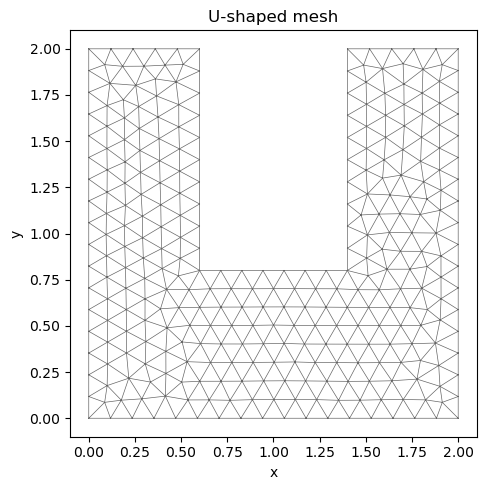

In [8]:
X_MAX   = 2.0
Y_MAX   = 2.0
NOTCH_X = (0.6, 1.4)
NOTCH_Y = 0.8
MESH_SIZE = 0.12

def in_u_shape(pts: np.ndarray) -> np.ndarray:
    x, y   = pts[:, 0], pts[:, 1]
    in_box = (x >= 0) & (x <= X_MAX) & (y >= 0) & (y <= Y_MAX)
    in_cut = (x > NOTCH_X[0]) & (x < NOTCH_X[1]) & (y > NOTCH_Y)
    return in_box & ~in_cut

u_polygon = [
    [0.0,        0.0     ],
    [X_MAX,      0.0     ],
    [X_MAX,      Y_MAX   ],
    [NOTCH_X[1], Y_MAX   ],
    [NOTCH_X[1], NOTCH_Y ],
    [NOTCH_X[0], NOTCH_Y ],
    [NOTCH_X[0], Y_MAX   ],
    [0.0,        Y_MAX   ],
]

with pygmsh.geo.Geometry() as geom:
    geom.add_polygon(u_polygon, mesh_size=MESH_SIZE)
    mesh = geom.generate_mesh(dim=2, verbose=False)

verts = mesh.points[:, :2].copy()
faces = mesh.cells_dict["triangle"].astype(np.int64)

used        = np.unique(faces)
remap       = np.full(len(verts), -1, dtype=np.int64)
remap[used] = np.arange(len(used))
verts       = verts[used]
faces       = remap[faces]

print(f"Mesh: {len(verts)} nodes, {len(faces)} triangles")

fig, ax = plt.subplots(figsize=(5, 5))
tri_vis = mtri.Triangulation(verts[:, 0], verts[:, 1], faces)
ax.triplot(tri_vis, "k-", lw=0.5, alpha=0.6)
ax.set_aspect("equal"); ax.set_title("U-shaped mesh")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()


## 3. Identify boundary nodes & assign BCs

Hot nodes  (u=1): 6
Cold nodes (u=0): 82
Interior nodes  : 223


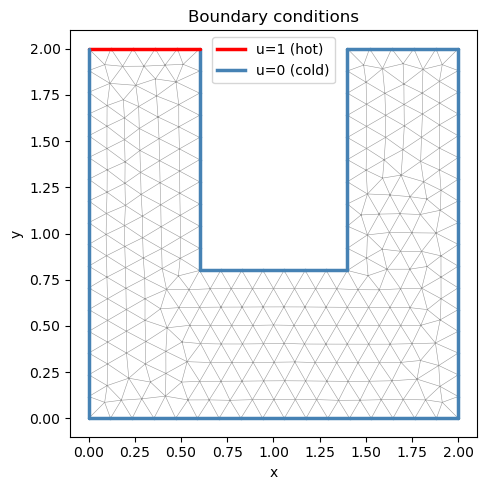

In [9]:
edge_count = Counter()
for tri_idx in faces:
    for i in range(3):
        e = tuple(sorted([tri_idx[i], tri_idx[(i + 1) % 3]]))
        edge_count[e] += 1

boundary_verts_idx = set()
for (v0, v1), cnt in edge_count.items():
    if cnt == 1:
        boundary_verts_idx.update([v0, v1])
boundary_verts_idx = np.array(sorted(boundary_verts_idx))

is_boundary = np.zeros(len(verts), dtype=bool)
is_boundary[boundary_verts_idx] = True

tol    = MESH_SIZE / 2
is_hot = (verts[:, 1] >= Y_MAX - tol) & (verts[:, 0] <= NOTCH_X[0] + tol) & is_boundary

print(f"Hot nodes  (u=1): {is_hot.sum()}")
print(f"Cold nodes (u=0): {(is_boundary & ~is_hot).sum()}")
print(f"Interior nodes  : {(~is_boundary).sum()}")

from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(5, 5))
ax.triplot(tri_vis, "k-", lw=0.4, alpha=0.4)
for (v0, v1), cnt in edge_count.items():
    if cnt == 1:
        color = "red" if (is_hot[v0] and is_hot[v1]) else "steelblue"
        ax.plot([verts[v0, 0], verts[v1, 0]], [verts[v0, 1], verts[v1, 1]],
                color=color, lw=2.5, solid_capstyle="round")
ax.legend(handles=[
    Line2D([0],[0], color="red",       lw=2.5, label="u=1 (hot)"),
    Line2D([0],[0], color="steelblue", lw=2.5, label="u=0 (cold)"),
])
ax.set_aspect("equal"); ax.set_title("Boundary conditions")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()


## 4. Finite-difference reference solution

Solve $-\Delta u = 0$ with a 5-point stencil on a 200×200 regular grid.
The resulting interpolant `fd_solution(x)` accepts `(n_pts, 2)` coordinates
and returns `(n_pts, 1)` values, used by the trainer to track the relative L2
error at every `print_each` checkpoint.

In [10]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.interpolate import LinearNDInterpolator

N_FD = 200
xs_fd = np.linspace(0, X_MAX, N_FD + 1)
ys_fd = np.linspace(0, Y_MAX, N_FD + 1)
h_fd  = xs_fd[1] - xs_fd[0]
XX_fd, YY_fd = np.meshgrid(xs_fd, ys_fd, indexing='ij')

pts_flat_fd  = np.column_stack([XX_fd.ravel(), YY_fd.ravel()])
active_fd    = in_u_shape(pts_flat_fd).reshape(N_FD + 1, N_FD + 1)
node_id_fd   = np.full((N_FD + 1, N_FD + 1), -1, dtype=np.int64)
node_id_fd[active_fd] = np.arange(active_fd.sum())
n_dof_fd     = active_fd.sum()
ii_fd, jj_fd = np.where(active_fd)

def _is_fd_bnd(i, j):
    if not active_fd[i, j]: return False
    for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
        ni, nj = i+di, j+dj
        if ni < 0 or ni > N_FD or nj < 0 or nj > N_FD or not active_fd[ni, nj]:
            return True
    return False

bnd_fd = np.array([_is_fd_bnd(i, j) for i, j in zip(ii_fd, jj_fd)])
hot_fd = bnd_fd & (YY_fd[ii_fd, jj_fd] >= Y_MAX - h_fd/2) & (XX_fd[ii_fd, jj_fd] <= NOTCH_X[0] + h_fd/2)

rows_fd, cols_fd, vals_fd = [], [], []
b_fd = np.zeros(n_dof_fd)
for idx, (i, j) in enumerate(zip(ii_fd, jj_fd)):
    k = node_id_fd[i, j]
    if bnd_fd[idx]:
        rows_fd.append(k); cols_fd.append(k); vals_fd.append(1.0)
        b_fd[k] = 1.0 if hot_fd[idx] else 0.0
    else:
        rows_fd.append(k); cols_fd.append(k); vals_fd.append(-4.0)
        for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
            nk = node_id_fd[i+di, j+dj]
            rows_fd.append(k); cols_fd.append(nk); vals_fd.append(1.0)

A_fd     = sp.csr_matrix((vals_fd, (rows_fd, cols_fd)), shape=(n_dof_fd, n_dof_fd))
u_fd_vec = spla.spsolve(A_fd, b_fd)
print(f"FD: {n_dof_fd} DOFs | u range [{u_fd_vec.min():.4f}, {u_fd_vec.max():.4f}]")

fd_interp = LinearNDInterpolator(
    pts_flat_fd[active_fd.ravel()], u_fd_vec, fill_value=np.nan
)

def fd_solution(x: np.ndarray) -> np.ndarray:
    """FD reference: (n_pts, 2) → (n_pts, 1), NaN outside domain."""
    vals   = fd_interp(x[:, :2]).reshape(-1, 1)
    in_dom = in_u_shape(x[:, :2]).reshape(-1, 1)
    vals[~in_dom] = np.nan
    return vals


FD: 30921 DOFs | u range [0.0000, 1.0000]


## 5. Domain & AlphaPINNNetwork

`AlphaPINNNetwork` replaces the GCN message-passing backbone with a **spectral
projection + FNN** pipeline:

| Step | Equation | Description |
|------|----------|-------------|
| Encode | $\alpha = \Phi^\top u$ | project nodal values onto K Laplace eigenvectors |
| Evolve | $\alpha' = \text{FNN}(\alpha)$ | compact MLP in spectral space |
| Decode | $u' = \Phi\,\alpha'$ | reconstruct nodal values |

Hard Dirichlet BCs and barycentric interpolation work identically to `GNNMeshNetwork`.

In [11]:
domain = DomainMesh((verts, faces))

domain.add_dirichlet(
    select=lambda v: is_hot,
    value=1.0,
    component=0,
    name="hot_top",
)
domain.add_dirichlet(
    select=lambda v: is_boundary & ~is_hot,
    value=0.0,
    component=0,
    name="cold_walls",
)
print(domain)


DomainMesh(2D, n_nodes=311, n_conditions=2)


In [21]:
# AlphaPINNNetwork: spectral basis size K, FNN width and depth
# K=32 is sufficient for smooth solutions on this mesh (~400 nodes)
# Increase K if you see spectral aliasing (sharp features not captured)
net = AlphaPINNNetwork(
    domain,
    n_eigenvectors  = 128,    # K — spectral resolution
    hidden_dim      = 128,   # FNN layer width
    n_layers        = 4,     # FNN depth
    activation      = 'tanh',
    n_outputs       = 1,
    hard_constraints = True,
    use_state       = False, # static PDE: no time-stepping state
)
print(net)


AlphaPINNNetwork: computing 128 Laplace eigenvectors for mesh with 311 nodes … done.
AlphaPINNNetwork(n_nodes=311, K=128, hidden_dim=128, n_layers=4, n_outputs=1, hard_constraints=True, use_state=False)


## 6. PDE problem (weak form)

Galerkin residual for $-\Delta u = 0$:

$$R(\phi) = \int_\Omega \nabla u \cdot \nabla \phi \, d\Omega = 0 \quad \forall\,\phi \in V_h$$

In [22]:
def volume_fn(x, y, params, phi, grad_phi, derivative=None):
    """Weak Laplacian residual: ∫ ∇u · ∇φ dΩ"""
    du_dx  = derivative(y, x, 0, (0,))
    du_dy  = derivative(y, x, 0, (1,))
    grad_u = jnp.stack([du_dx, du_dy], axis=-1)   # (n_pts, 2)
    return jnp.sum(grad_u * grad_phi, axis=-1)      # (n_pts,)

problem = ProblemWeak(
    domain=domain,
    volume_fn=volume_fn,
    params={},
    input_names=["x", "y"],
    output_names=["u"],
    lagrange_multipliers=["pde", "hot_top", "cold_walls"],
    cubature_order=4,
    solution=fd_solution,
)

problem.show_problem()


<IPython.core.display.Math object>

'\\min_{\\theta}\\max_{\\boldsymbol{\\lambda}_{pde},\\boldsymbol{\\lambda}_{hot\\_top},\\boldsymbol{\\lambda}_{cold\\_walls}}\\;\\mathcal{L}(\\theta,\\boldsymbol{\\lambda})=\\frac{w_{pde}}{N_e}\\sum_e\\!\\left(\\int_{K_e}\\nabla u_h\\cdot\\nabla\\phi\\,dK\\right)^2 + \\frac{1}{N_e}\\langle\\boldsymbol{\\lambda}_{pde},\\,\\mathbf{R}_{pde}\\rangle + \\frac{w_{hot\\_top}}{N_{hot\\_top}}\\left\\|\\mathcal{B}_{hot\\_top}\\right\\|_2^2 + \\frac{1}{N_{hot\\_top}}\\langle\\boldsymbol{\\lambda}_{hot\\_top},\\,\\mathcal{B}_{hot\\_top}\\rangle + \\frac{w_{cold\\_walls}}{N_{cold\\_walls}}\\left\\|\\mathcal{B}_{cold\\_walls}\\right\\|_2^2 + \\frac{1}{N_{cold\\_walls}}\\langle\\boldsymbol{\\lambda}_{cold\\_walls},\\,\\mathcal{B}_{cold\\_walls}\\rangle \\\\[4pt] \\begin{array}{l} K_e:\\text{ mesh element (triangle)} \\\\ N_e:\\text{ number of elements} \\\\ w_{pde}:\\text{ PDE weight} \\\\ \\boldsymbol{\\lambda}_{pde}:\\text{ Lagrange multipliers for PDE} \\\\ \\mathcal{B}_{hot\\_top}:\\text{ Dirichl

## 7. Training

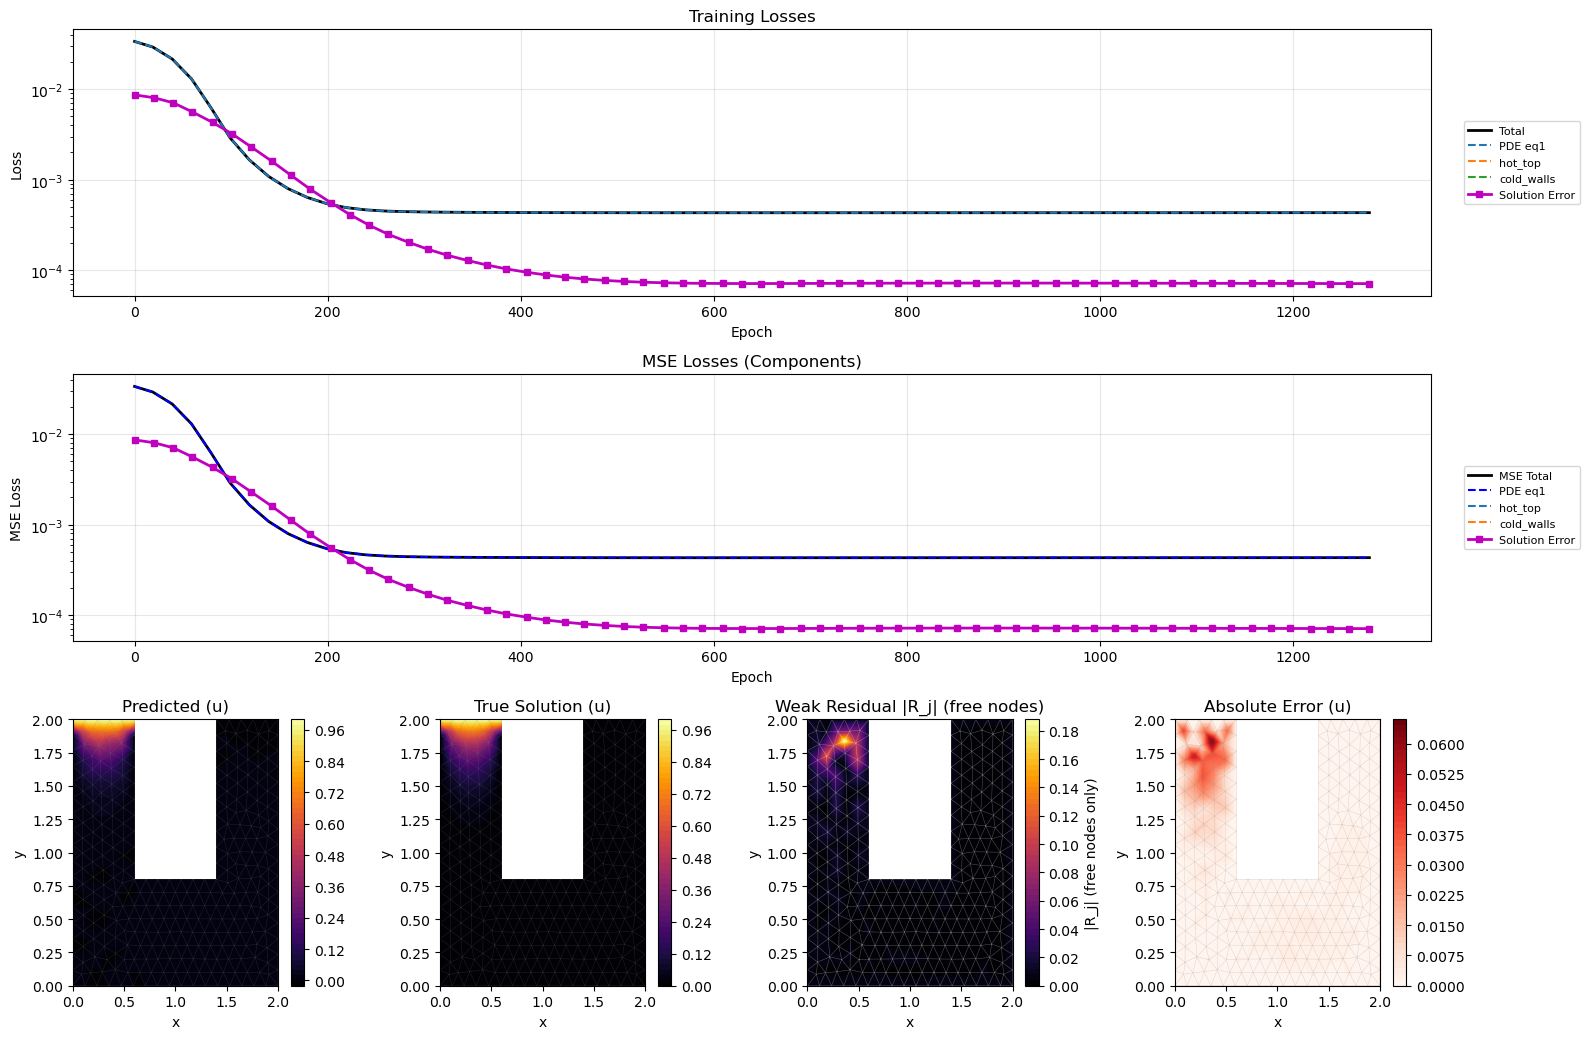

Starting Trainer (JAX, Lagrangian mode) for 10000 epochs...
Epoch 0/10000 | MSE Loss: 3.37e-02 | PDE: 3.37e-02 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00]
Epoch 20/10000 | AL Loss: 2.92e-02 | MSE Loss: 2.92e-02 | PDE: 2.92e-02 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 1.1s | Error: 8.67e-03
Epoch 40/10000 | AL Loss: 2.16e-02 | MSE Loss: 2.16e-02 | PDE: 2.16e-02 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 1.6s | Error: 8.06e-03
Epoch 60/10000 | AL Loss: 1.31e-02 | MSE Loss: 1.30e-02 | PDE: 1.30e-02 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 2.1s | Error: 7.09e-03
Epoch 80/10000 | AL Loss: 6.32e-03 | MSE Loss: 6.28e-03 | PDE: 6.28e-03 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 2.9s | Error: 5.61e-03
Epoch 100/10000 | AL Loss: 2.92e-03 | MSE Loss: 2.90e-03 | PDE: 2.90e-03 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 3.4s | Error: 4.29e-03
Epoch 120/10000 | AL Loss: 1.67e-03 | MSE Loss: 1.65e-03 | PDE: 1.65e-03 | BCs:

In [ ]:
trainer = Trainer(problem, net)
trainer.compile(
    epochs      = 10000,
    weights     = {"pde": 1.0, "hot_top": 1.0, "cold_walls": 1.0},
    learning_rate = 1e-4,
    lagrange_lr = 1e-5,
    print_each  = 500,
    show_plots  = True,
)
trainer.train()
